<a href="https://colab.research.google.com/github/clubdeprogramacionez-coder/Well-Tech-Data-Pipeline/blob/main/Analisis_y_Correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 PROYECTO FINAL : Correlacion de Pozos Y Producción Petrolera


---



## 📊 ¿Qué es Matplotlib?
Matplotlib es una biblioteca de trazado de gráficos de bajo nivel en Python que sirve como utilidad de visualización.


## Crear un objeto figure simple

En este paso, crearás los objetos fundamentales para cualquier gráfico:

1. Figure: El lienzo completo de tu visualización.

2. Axes: La zona dentro del lienzo donde se dibuja un gráfico.

3. Eje (Axis): Las líneas de referencia (X/Y) que marcan las escalas dentro de los Axes.

4. Gráfico (Plot/Graph): La visualización de datos (líneas, barras, puntos) dibujada sobre los Ejes, dentro de los Axes.

La forma más común de crear una figura y un conjunto de subplots (axes) es con la función plt.subplots(). Esta función devuelve una tupla que contiene un objeto Figure y un objeto Axes (o un array de objetos Axes).

In [ ]:
import matplotlib.pyplot as plt

## Create a Figure and an Axes object
fig, ax = plt.subplots()

## Save the figure to a file
plt.savefig('empty_plot.png')

## 📒📃 Qué es exactamente un CSV
CSV (Comma-Separated Values) es un formato de texto plano para tablas. Cada línea es una fila; cada columna está separada por un delimitador, normalmente la coma.

Esta es la opción de la librería estándar: viene con Python, no instalas nada.

Caso simple: csv.reader



```python
import csv

usuarios = '/ruta/a/tu/usuarios.csv'

with open(usuarios, encoding="utf-8") as archivo:
    lector = csv.reader(archivo)
    for fila in lector:
        print(fila)
```






---


# 📊📈⚫: Laboratorio 10: Pipeline de Datos para Evaluación de Formaciones Geológicas

Mediante la correlación estratigráfica, los geólogos identifican qué zonas tienen las propiedades petrofísicas necesarias para almacenar hidrocarburos.


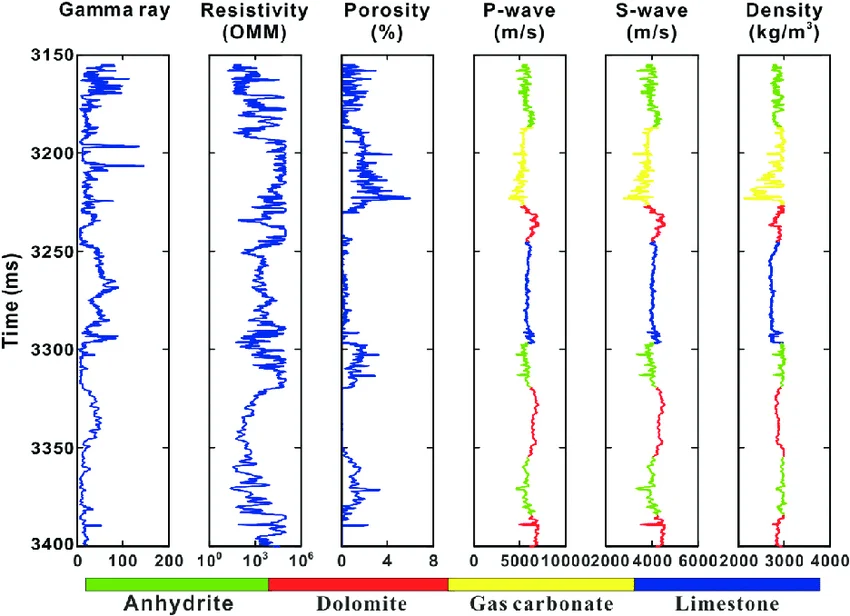


Imaginen que tenemos este registro del Pozo A y otro diferente del Pozo B. Python nos permite automatizar la lectura de estas curvas para identificar automáticamente dónde empiezan y terminan las zonas de arena.

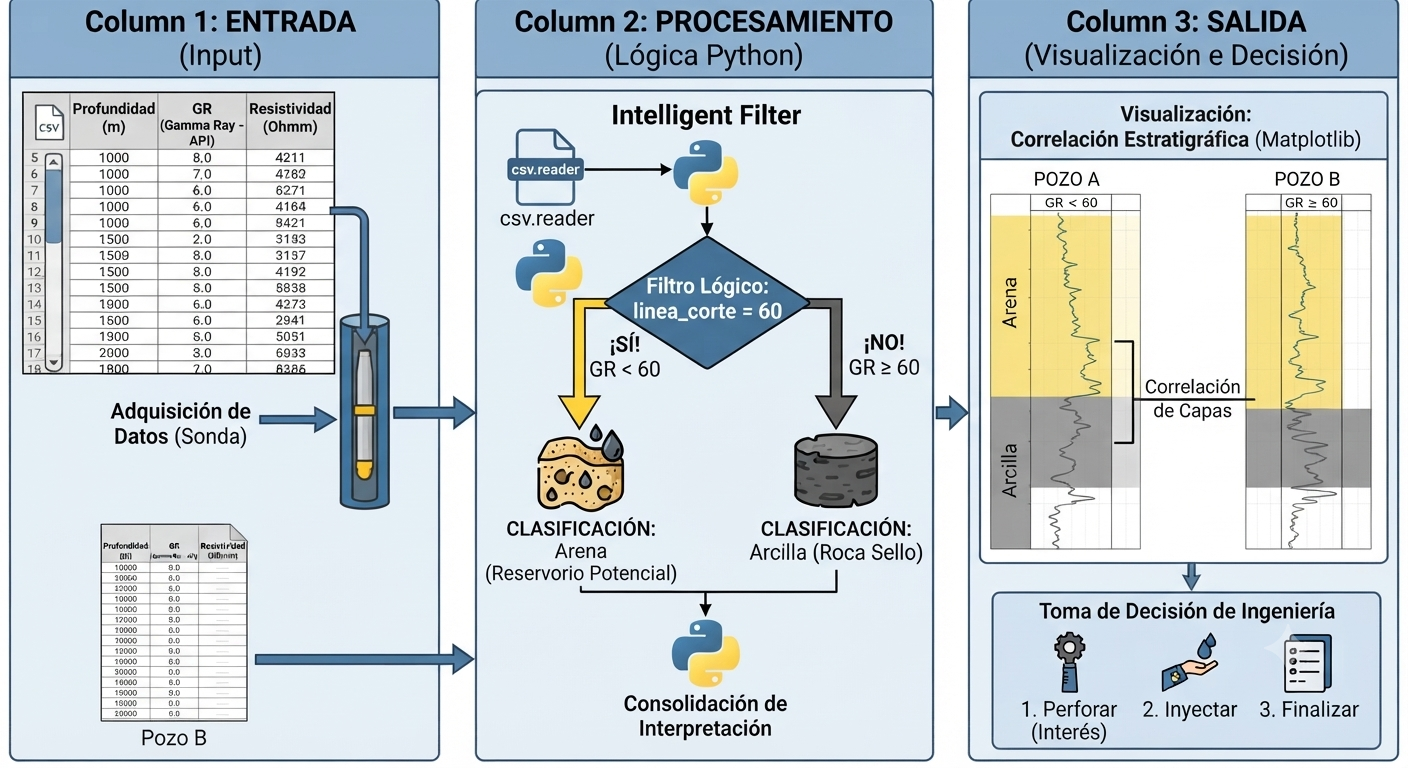

Gemini. (2026). Diagrama de flujo: Pipeline de datos para la evaluación de formaciones geológicas [Infografía didáctica]. Generado por inteligencia artificial para el curso de Arquitectura de Datos y Evaluación de Formaciones.

## Instalar librerias y usar librerias.

Esto porque el proyecto y el laboratorio usaremos en escencia mathplotlib para graficar.

```powershell
pip install matplotlib
pip install csv
```

abre la terminal y copia y pega(el entorno de colab ya tiene instalado la libreria mathplotli.pyplot, a menos que lo ocupes en tu entorno local usando un IDE)

## Importar y llamarlas

Con la palabra `import` nos permite utilizar mathplotlib. Por que usamos `as` plt en  mi codigo: porque `as` traducido en español es `como`, por lo tanto `mathplotli.pyplot` es como `plt`

In [85]:
import matplotlib.pyplot as plt
import csv

## INICIALIZAMOS LAS LISTAS Y OCUPAMOS LAS RUTAS DE LOS DATOS.

Si el laboratorio utiliza dos pozos, nuestras variables que vamos a declarara son listas vacias que esperan datos del archivo de excel `csv`. Creamos dos variables que almacenaran las rutas o dirreciones donde se ubican los dos archivos `csv`

In [86]:
# POZO A
profundidad_PozoA = []
gr_PozoA = []

# POZO B
profundidad_PozoB = []
gr_PozoB = []

# Ruta de datos del Pozo A
csv_pozoA = '/content/geological_well_data_A.csv'

# Ruta de datos del Pozo B
csv_pozoB = '/content/geological_well_data_B.csv'

In [ ]:
with open(csv_pozoA, 'r') as pozo_a:
  file_reader = csv.reader(pozo_a)

  header = next(file_reader)

  for fila_completa in file_reader:
    profundidad_PozoA.append(float(fila_completa[0]))
    gr_PozoA.append(float(fila_completa[1]))

In [87]:


with open(csv_pozoB, 'r') as pozo_b:
  file_reader = csv.reader(pozo_b)

  header = next(file_reader)

  for fila_completa in file_reader:
    profundidad_PozoB.append(float(fila_completa[0]))
    gr_PozoB.append(float(fila_completa[1]))

## Interpretación del Registro de Rayos Gamma

 Al aplicar la linea_corte en 60 API, el gráfico resalta eficazmente las zonas interpretadas como arenisca y lutita.

In [88]:
linea_corte = 60

In [ ]:
# 3. CREAR LOS DOS CARRILES EN PARALELO (Compartiendo el eje Y de profundidad)
fig, ax = plt.subplots(1, 2, figsize=(8, 7), sharey=True)
""" DETALLES
Figure = fig: El lienzo completo de tu visualización.

Axes= ax: La zona dentro del lienzo donde se dibuja un gráfico.

figsize(8,7) donde 8 corresponde al ancho y 7 a la altura de la figura.

sharey=True para compartir el eje y entre los subplots.
"""
# -------------------------------- PANEL 1: POZO A ------------------------------------
ax[0].plot(gr_PozoA, profundidad_PozoA, color='black', linewidth=1.5)
""" DETALLES
grosor de línea igual a 1.5 para una línea en gráficos, diagramas o visualizaciones.
"""

ax[0].fill_betweenx(profundidad_PozoA, gr_PozoA, linea_corte,
                    where=[x < linea_corte for x in gr_PozoA], facecolor='gold', alpha=0.5)
""" DETALLES
fill_betweenx se utiliza para rellenar el área entre dos curvas a lo
  largo del eje Y en un gráfico

when = se utiliza para especificar la condición booleana.
  cuando dice when menciona el área sombreada que se dibuja
  solo donde los valores de gr_PozoA son menores que linea_corte,
  permitiéndote destacar visualmente la parte del gráfico que cumpla
  esa condición permitiendo colorear debajo de la curva el color dorado.

facecolor=(gold/black) se utiliza para determinar el color de fondo de ciertos
  elementos gráficos

alpha=0.5, estamos indicando que el objeto se dibujará con 50% de opacidad-

"""
ax[0].fill_betweenx(profundidad_PozoA, gr_PozoA, linea_corte,
                   where=[x >= linea_corte for x in gr_PozoA], facecolor='gray', alpha=0.4)
""" DETALLES
cuando dice when menciona el área sombreada que se dibuja
solo donde los valores de gr_PozoA son mayores o iguales que la
linea_corte de rayos gamma, permitiéndote destacar visualmente
la parte del gráfico que cumpla esa condición permitiendo colorear
debajo de la curva el color gris.
"""
ax[0].set_title('POZO A (Exploratorio)', fontsize=11, fontweight='bold', pad=15)
""" DETALLES
fontsize=11: Establece el tamaño de fuente.
fontweight='bold': Aplica negrita para resaltar el encabezado.
pad=15: Aumenta la separación (padding) de 15 puntos entre el título
  y la parte superior del área de trazado, evitando que el texto choque
  con el borde superior.
"""
ax[0].set_xlabel('Rayos Gamma (API)')
""" DETALLES
Etiqueta el eje X
"""
ax[0].set_ylabel('Profundidad Verdadera (Pies)')
""" DETALLES
Etiqueta el eje y
"""
ax[0].xaxis.tick_top() # Escala arriba
""" DETALLES
Mueve las marcas y los valores del eje X al borde superior del gráfico.
"""
ax[0].xaxis.set_label_position('top')
""" DETALLES
Posiciona la etiqueta del eje X (definida previamente) en la parte superior.
"""
ax[0].set_xlim(0, 150)
""" DETALLES
Define los límites mínimos y máximos del eje X.
"""
ax[0].grid(True, linestyle=':')
""" DETALLES
True: Enciende la rejilla.

linestyle=':': Configura el estilo de línea como punteada, lo cual es menos
invasivo visualmente y facilita la lectura precisa de los valores de
la curva al cruzarla con las guías.
"""
# ----------------------------- FIN DEL PANEL 1: POZO A ---------------------

# ------------------------------- PANEL 2: POZO B ---------------------------
ax[1].plot(gr_PozoB, profundidad_PozoB, color='black', linewidth=1.5)
ax[1].fill_betweenx(profundidad_PozoB, gr_PozoB, linea_corte,
                    where=[x < linea_corte for x in gr_PozoB], facecolor='gold', alpha=0.5)
ax[1].fill_betweenx(profundidad_PozoB, gr_PozoB, linea_corte,
                    where=[x >= linea_corte for x in gr_PozoB], facecolor='gray', alpha=0.4)
ax[1].set_title('POZO B (Delimitador)', fontsize=11, fontweight='bold', pad=15)
ax[1].set_xlabel('Rayos Gamma (API)')
ax[1].xaxis.tick_top()
ax[1].xaxis.set_label_position('top')
ax[1].set_xlim(0, 150)
ax[1].grid(True, linestyle=':')
# ------------------------------- FIN DEL PANEL 2: POZO B ---------------------

# ------ Establecer los límites del eje Y para la profundidad deseada --------
ax[0].set_ylim(1100, 1000) # De 1000 (arriba) a 1100 (abajo) debido a invert_yaxis
ax[0].invert_yaxis() # Invierte el eje Y para AMBOS pozos gracias a sharey=True

# Título principal del proyecto
plt.suptitle('CORRELACIÓN ESTRATIGRÁFICA SENCILLA', fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

""" DETALLES
plt.tight_layout(): Ajusta automáticamente los parámetros de la
   subtrama para que el contenido se ajuste perfectamente al área de la figura.

plt.show(): Despliega la ventana gráfica en tu entorno de desarrollo o renderiza
   la imagen
"""



---


# ANALISIS de la Correlación Estratigráfica

El gráfico muestra los registros de Rayos Gamma para dos pozos: Pozo A (Exploratorio) y Pozo B (Delimitador), ambos graficados contra la Profundidad Verdadera en pies. Ambos pozos cubren un intervalo de profundidad similar, aproximadamente de 1000 a 1100 pies(en los registros es de 1000 -1500, solo para visualizar por partes fue un rango de 1000 - 1100 pies).


* ¿Qué zona de profundidad (dentro del rango 1000–1100 pies) muestra la mejor calidad de reservorio según la presencia de areniscas (relleno dorado) en ambos pozos?

* ¿Es posible afirmar que la litología encontrada en el Pozo A es un buen indicador de lo que encontraremos en el Pozo B? ¿Por qué?

* Si el corte de 60 API separa lutitas de areniscas, ¿cuál de los dos pozos parece tener una mayor proporción de lutitas (material radiactivo) en los primeros 100 pies de profundidad?

## ♒ Práctica 10: Dashboard de Producción Petrolera

**Objetivo: Desarrollar un dashboard que visualice el rendimiento de los pozos, permitiendo identificar tendencias y volúmenes de producción.**

Requerimientos del Dashboard:
Debes crear una figura con tres secciones (usando matplotlib):

- Gráfica 1 (Producción Mensual): Un gráfico de barras que muestre la producción por mes para cada pozo.

- Gráfica 2 (Producción Acumulada): Un gráfico de línea que muestre el total acumulado a lo largo del tiempo.

- Gráfica 3 (Distribución): Un gráfico de pastel que muestre el porcentaje de participación de cada pozo en la producción total.

Reglas de la Práctica:

1. Entrada de datos: Deben leer el archivo produccion_petrolera.csv usando la librería csv (sin usar pandas).

2. Lógica: Deben sumar los totales de cada pozo para poder generar el gráfico de pastel.

3. Calidad: El dashboard debe tener títulos claros en cada gráfica y etiquetas en los ejes.